# Dynamic Bus Ticket Demand Scoring System

Interactive notebook that computes a **Demand Score** from manually entered inputs,
visualizes all nonlinear building blocks (sigmoid, tanh, log) and intermediate
variables, and outputs the final score.

## Model

**1) Gap between expected and actual occupancy**

```
fill_pct = OP / OP_exp × 100              # چند درصد از هدف پر شده (مثلاً 0 از 40 → 0%)
gap_pct  = 100 - fill_pct                 # منفی اگر OP > OP_exp (فروش بیش از انتظار)
gap_unit = gap_pct / 100                  # می‌تواند منفی باشد
G        = sigmoid(k_g * gap_unit - shift)
```

**2) Demand intensity**

```
DI_raw = O^1.5 * SR
DI     = sigmoid(k_d * log(1 + DI_raw))
```

**3) Final score**

```
Score = w_g * G + w_d * DI
```

Sections: **Imports → Functions → Model → Visualization → Interactive input**.

## 1. Imports

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ipywidgets is optional: the notebook falls back to a plain function call
# if widgets are not available in the current environment.
try:
    import ipywidgets as widgets
    _HAS_WIDGETS = True
except Exception:
    widgets = None
    _HAS_WIDGETS = False

# Plotly for zoom/pan on the final interactive chart.
try:
    import plotly.graph_objects as go
    _HAS_PLOTLY = True
except Exception:
    _HAS_PLOTLY = False

# Readable plots.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Imports OK. ipywidgets:", _HAS_WIDGETS, "| plotly:", _HAS_PLOTLY)

Imports OK. ipywidgets: True | plotly: False


## 2. Functions

Numerically safe building blocks:

- `sigmoid(x)` — logistic squashing function, overflow-safe.
- `fill_pct(OP, OP_exp)` — چند درصد از OP مورد انتظار پر شده (مثلاً ۱۶ از ۴۰ → ۴۰٪).
- `gap_pct(OP, OP_exp)` — درصد باقی‌مانده تا هدف: `100 - fill_pct` (۰ از ۴۰ → گپ ۱۰۰٪).
- `gap_function(gap_unit, k_g)` — سیگموید؛ gap_unit=0 وقتی هدف پر شده، gap_unit=1 وقتی ۰٪ از هدف پر شده.
- `demand_intensity(O, SR, k_d)` — log-based demand intensity with clipping.
- helper `safe_log1p` to prevent overflow / invalid input in `log(1 + x)`.

In [96]:
def sigmoid(x):
    """Overflow-safe logistic sigmoid: 1 / (1 + exp(-x)).

    Works element-wise on scalars and numpy arrays. The argument is clipped
    to avoid `exp` overflow warnings for very large magnitudes.
    """
    x = np.clip(np.asarray(x, dtype=float), -500.0, 500.0)
    return 1.0 / (1.0 + np.exp(-x))


def safe_log1p(x):
    """Compute log(1 + x) while preventing invalid/overflow issues.

    Negative DI_raw is impossible in this model, but we still clip the lower
    bound to 0 so the logarithm is always defined.
    """
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0.0, 1e300)  # 1 + x stays positive and finite
    return np.log1p(x)


def fill_pct(OP, OP_exp):
    """Share of expected occupancy achieved (%). Can exceed 100 if OP > OP_exp.

    Example: OP=0, OP_exp=0.40 -> 0% filled.
    Example: OP=0.84, OP_exp=0.70 -> 120% filled (oversold vs target).
    """
    OP = np.clip(np.asarray(OP, dtype=float), 0.0, 1.0)
    OP_exp = np.asarray(OP_exp, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(OP_exp > 0, OP / OP_exp, 0.0)
    ratio = np.maximum(ratio, 0.0)
    return ratio * 100.0


def gap_pct(OP, OP_exp):
    """Remaining share of the target (%). Negative when OP > OP_exp (oversold).

    Example: OP=0.84, OP_exp=0.70 -> fill 120% -> gap = -20%.
    """
    return 100.0 - fill_pct(OP, OP_exp)


def gap_unit(OP, OP_exp):
    """Normalized gap: gap_pct / 100 (can be negative)."""
    return gap_pct(OP, OP_exp) / 100.0


def gap_function(gap_unit, k_g, g_at_zero=0.25):
    """Sigmoid on normalized gap; extends smoothly for negative gap (oversold).

    gap_unit=0   (0% gap, target reached) -> G ~= g_at_zero
    gap_unit=1   (100% gap, empty)       -> sigmoid argument = k_g (default 3)
    gap_unit<0   (oversold)              -> G continues below g_at_zero
    """
    gap_unit = np.asarray(gap_unit, dtype=float)
    shift = np.log((1.0 - g_at_zero) / g_at_zero)
    return sigmoid(k_g * gap_unit - shift)


def demand_intensity(O, SR, k_d, order_exp=1.5):
    """Log-based demand intensity.

    DI_raw = O^order_exp * SR
    DI     = sigmoid(k_d * log(1 + DI_raw))

    Inputs are clipped to sane, non-negative ranges to avoid invalid powers
    (negative base ** fractional exponent) and numerical blow-ups.
    """
    O = np.clip(np.asarray(O, dtype=float), 0.0, 1e9)
    SR = np.clip(np.asarray(SR, dtype=float), 0.0, 1.0)

    DI_raw = np.power(O, order_exp) * SR
    DI = sigmoid(k_d * safe_log1p(DI_raw))
    return DI


# Quick smoke tests of the primitives.
print("sigmoid(0)       =", sigmoid(0.0))
print("sigmoid(1e6)     =", sigmoid(1e6))
print("0/40 filled      =", fill_pct(0.0, 0.40), "% -> gap =", gap_pct(0.0, 0.40), "%")
print("0/80 filled      =", fill_pct(0.0, 0.80), "% -> gap =", gap_pct(0.0, 0.80), "%")
print("32/40 filled     =", fill_pct(0.32, 0.40), "% -> gap =", gap_pct(0.32, 0.40), "%")
print("32/80 filled     =", fill_pct(0.32, 0.80), "% -> gap =", gap_pct(0.32, 0.80), "%")
print("40/40 filled     =", fill_pct(0.40, 0.40), "% -> gap =", gap_pct(0.40, 0.40), "%")
print("84/70 oversold   =", fill_pct(0.84, 0.70), "% -> gap =", gap_pct(0.84, 0.70), "%")
print("demand_intensity =", demand_intensity(50, 0.7, 1.0))

sigmoid(0)       = 0.5
sigmoid(1e6)     = 1.0
0/40 filled      = 0.0 % -> gap = 100.0 %
0/80 filled      = 0.0 % -> gap = 100.0 %
32/40 filled     = 80.0 % -> gap = 20.0 %
32/80 filled     = 40.0 % -> gap = 60.0 %
40/40 filled     = 100.0 % -> gap = 0.0 %
84/70 oversold   = 120.0 % -> gap = -20.0 %
demand_intensity = 0.9959917811217828


## 3. Model

The scoring function is **conditional** on a boolean flag `sales_pressure`:

```
if sales_pressure:   # sales-pressure mode -> gap + demand intensity
    Score = w_g * G + w_d * DI
else:                # occupancy-only mode -> just the OP/gap part
    Score = w_g * G
```

When `sales_pressure = True` the score reacts to sales pressure (the `DI` term is
included). When `False` the score depends **only** on the occupancy gap (`OP`).

Default coefficients are stored in `DEFAULTS` so every plot and the interactive
widget share the same baseline. `score_model(...)` returns a dictionary with all
intermediate variables so they can be inspected and plotted.

In [97]:
# Shared default parameters (user editable).
DEFAULTS = dict(
    OP=0.55,      # actual occupancy proportion (0..1)
    OP_exp=0.70,  # expected occupancy proportion (0..1)
    O=20,         # order count (>= 0)
    SR=15,        # sales rate (0..1)
    k_g=3.0,      # gap sensitivity
    k_d=0.1,      # demand sensitivity
    w_g=0.5,      # weight on gap signal
    w_d=0.5,      # weight on demand intensity
    g0=0.25,      # G at 0% gap (target reached); shift = ln((1-g0)/g0)
    order_exp=1.5,  # exponent on O in DI_raw = O^order_exp * SR
    chart_gap_min=-50.0,  # gap_pct axis min on charts (%)
    chart_gap_max=100.0,  # gap_pct axis max on charts (%)
    sales_pressure=False,  # if True: Score reacts to sales pressure (gap + DI)
                          # if False: Score depends only on the OP/gap part
)


def score_model(OP, OP_exp, O, SR, k_g, k_d, w_g, w_d, sales_pressure=True,
                g0=0.25, order_exp=1.5):
    """Conditional demand scoring model.

    sales_pressure True  -> Score = w_g * G + w_d * DI  (gap + sales pressure)
    sales_pressure False -> Score = w_g * G             (occupancy / OP only)

    Returns a dict with the intermediate variables (gap, G, DI_raw, DI) and the
    final Score. Accepts scalars or numpy arrays for vectorized plotting.
    """
    OP_a = np.clip(np.asarray(OP, dtype=float), 0.0, 1.0)
    OP_exp_a = np.asarray(OP_exp, dtype=float)

    fill = fill_pct(OP_a, OP_exp_a)
    g_pct = gap_pct(OP_a, OP_exp_a)
    g_unit = gap_unit(OP_a, OP_exp_a)
    gap_abs = OP_exp_a - OP_a

    G = gap_function(g_unit, k_g, g_at_zero=g0)
    DI = demand_intensity(O, SR, k_d, order_exp=order_exp)

    # Recompute DI_raw for reporting/plotting (mirrors demand_intensity logic).
    O_c = np.clip(np.asarray(O, dtype=float), 0.0, 1e9)
    SR_c = np.clip(np.asarray(SR, dtype=float), 0.0, 1.0)
    DI_raw = np.power(O_c, order_exp) * SR_c

    shift = float(np.log((1.0 - g0) / g0))

    # Conditional score: include the demand-intensity (sales pressure) term only
    # when sales_pressure is True; otherwise keep just the OP/gap contribution.
    if sales_pressure:
        Score = w_g * G + w_d * DI
    else:
        Score = w_g * G + 0.0 * DI  # 0*DI keeps shape when DI is an array
    return dict(gap=gap_abs, fill_pct=fill, gap_pct=g_pct, gap_unit=g_unit,
                g0=g0, shift=shift, order_exp=order_exp,
                G=G, DI_raw=DI_raw, DI=DI, Score=Score)


# Sanity check with defaults.
score_model(**DEFAULTS)

TypeError: score_model() got an unexpected keyword argument 'chart_gap_min'

## 4. Visualization

Each plot is in its **own separate figure** and uses **matplotlib only**.

- **A** sigmoid curve, x ∈ [-10, 10]
- **B** tanh curve, x ∈ [-10, 10]
- **C** demand intensity: DI vs O (SR fixed) and DI vs SR (O fixed)
- **D** score sensitivity: Score vs OP_gap, Score vs O, Score vs SR

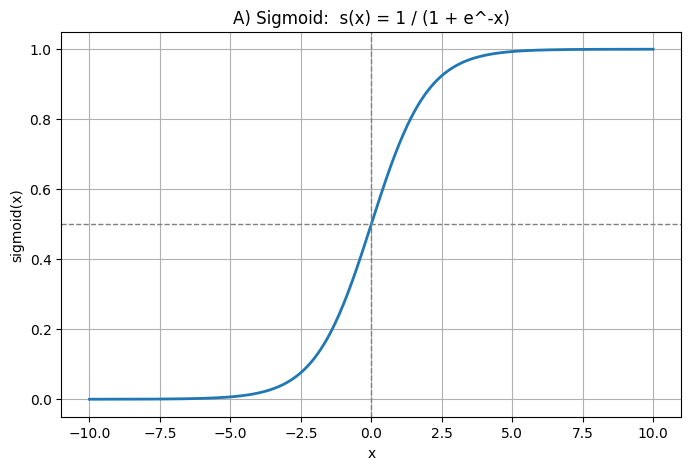

In [ ]:
# A) Sigmoid curve
x = np.linspace(-10, 10, 400)
y = sigmoid(x)

plt.figure()
plt.plot(x, y, color="tab:blue", lw=2)
plt.axhline(0.5, color="gray", ls="--", lw=1)
plt.axvline(0.0, color="gray", ls="--", lw=1)
plt.title("A) Sigmoid:  s(x) = 1 / (1 + e^-x)")
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.show()

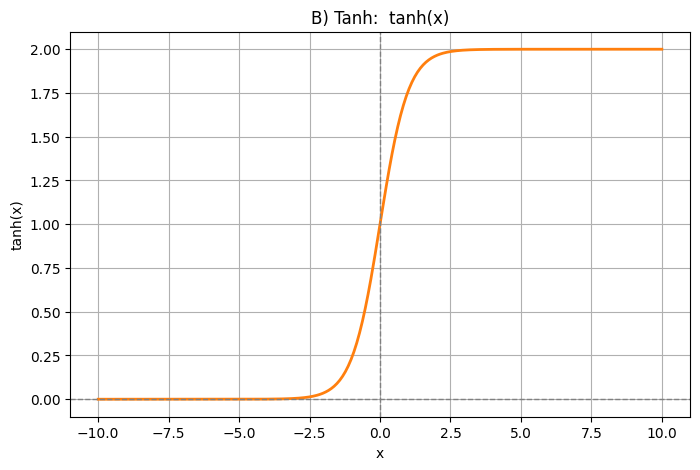

In [ ]:
# B) Tanh curve
x = np.linspace(-10, 10, 400)
y = np.tanh(x)+np.int16(1)

plt.figure()
plt.plot(x, y, color="tab:orange", lw=2)
plt.axhline(0.0, color="gray", ls="--", lw=1)
plt.axvline(0.0, color="gray", ls="--", lw=1)
plt.title("B) Tanh:  tanh(x)")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.show()

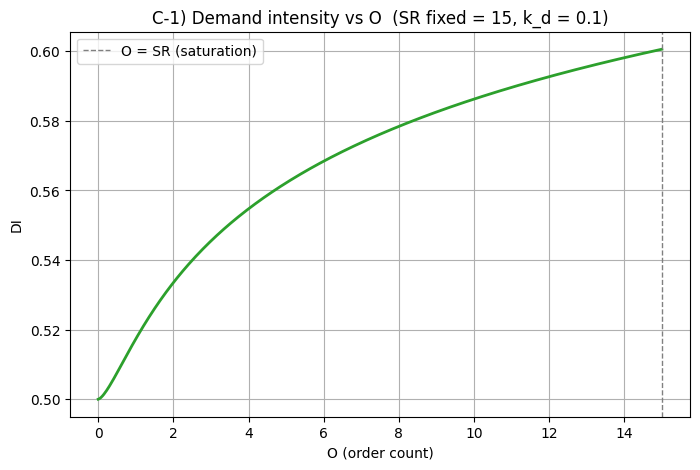

In [ ]:
# C-1) Demand intensity as a function of O (SR fixed)
# O ranges from 0 up to SR (since SR >= O); DI -> 1 as O -> SR.
SR_fixed = DEFAULTS["SR"]
k_d = DEFAULTS["k_d"]
O_grid = np.linspace(0, SR_fixed, 400)
DI_vs_O = demand_intensity(O_grid, SR_fixed, k_d)

plt.figure()
plt.plot(O_grid, DI_vs_O, color="tab:green", lw=2)
plt.axvline(SR_fixed, color="gray", ls="--", lw=1, label="O = SR (saturation)")
plt.title(f"C-1) Demand intensity vs O  (SR fixed = {SR_fixed}, k_d = {k_d})")
plt.xlabel("O (order count)")
plt.ylabel("DI")
plt.legend()
plt.show()

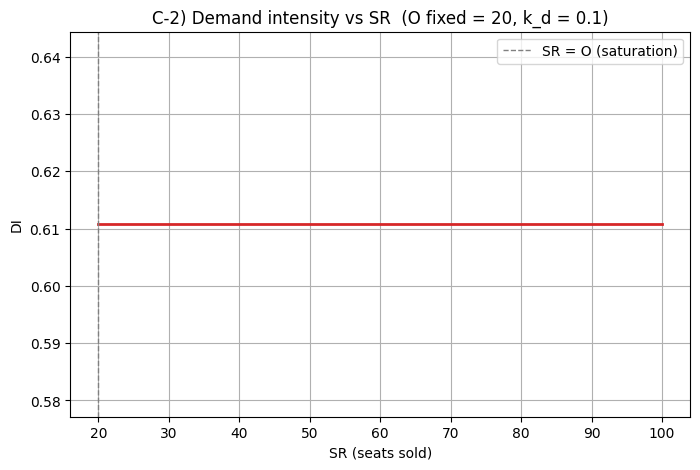

In [ ]:
# C-2) Demand intensity as a function of SR (O fixed)
# SR ranges from O upward (SR >= O). DI is highest when SR == O and decays as
# SR grows (orders become a smaller fraction of seats sold).
O_fixed = DEFAULTS["O"]
k_d = DEFAULTS["k_d"]
SR_grid = np.linspace(O_fixed, O_fixed * 5, 400)
DI_vs_SR = demand_intensity(O_fixed, SR_grid, k_d)

plt.figure()
plt.plot(SR_grid, DI_vs_SR, color="tab:red", lw=2)
plt.axvline(O_fixed, color="gray", ls="--", lw=1, label="SR = O (saturation)")
plt.title(f"C-2) Demand intensity vs SR  (O fixed = {O_fixed}, k_d = {k_d})")
plt.xlabel("SR (seats sold)")
plt.ylabel("DI")
plt.legend()
plt.show()

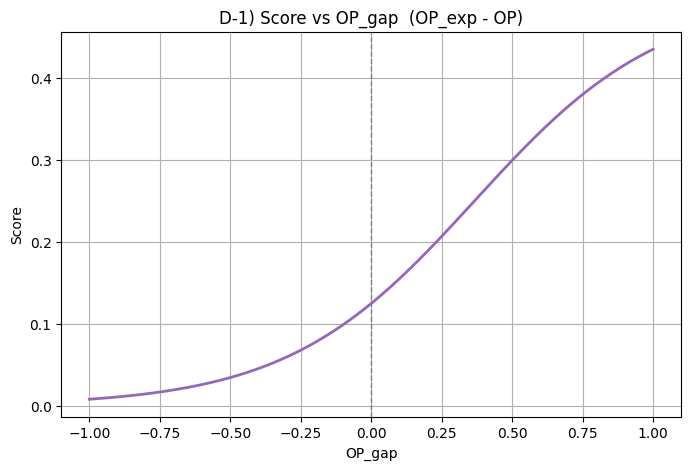

In [ ]:
# D-1) Score vs gap_pct  (unfilled % of target)
p = dict(DEFAULTS)
OP_exp_fixed = 0.80
OP_grid = np.linspace(0.0, min(1.0, OP_exp_fixed * 1.3), 400)
res = score_model(
    OP=OP_grid, OP_exp=OP_exp_fixed,
    O=p["O"], SR=p["SR"],
    k_g=p["k_g"], k_d=p["k_d"], w_g=p["w_g"], w_d=p["w_d"],
    g0=p["g0"], order_exp=p["order_exp"],
    sales_pressure=p["sales_pressure"],
)

plt.figure()
plt.plot(res["gap_pct"], res["Score"], color="tab:purple", lw=2)
plt.axvline(0.0, color="gray", ls="--", lw=1, label="هدف کامل (gap=0%)")
plt.title(f"D-1) Score vs gap_pct  (OP_exp={OP_exp_fixed})")
plt.xlabel("gap_pct (%) — درصد باقی‌مانده تا هدف")
plt.ylabel("Score")
plt.legend()
plt.show()

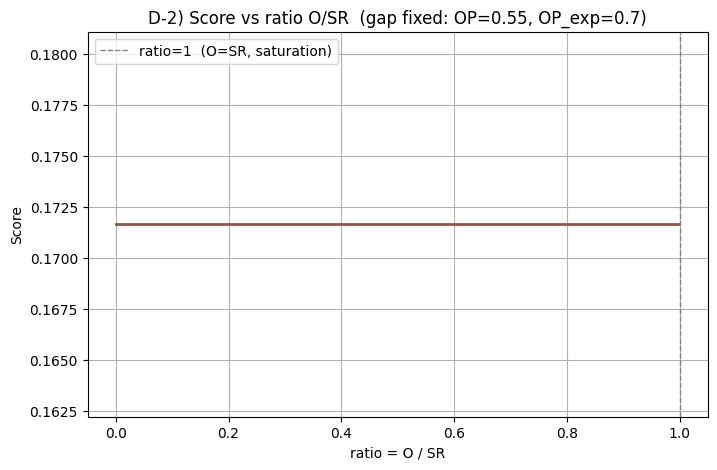

In [ ]:
# D-2) Score vs ratio = O / SR  (gap fixed at default)
# We sweep ratio in (0, 1) by setting O = ratio and SR = 1.
# Gap (OP, OP_exp) stays fixed so only the DI component changes.
p = dict(DEFAULTS)
ratio_grid = np.linspace(1e-4, 1 - 1e-4, 400)
res = score_model(
    OP=p["OP"], OP_exp=p["OP_exp"],
    O=ratio_grid, SR=np.ones_like(ratio_grid),
    k_g=p["k_g"], k_d=p["k_d"], w_g=p["w_g"], w_d=p["w_d"],
    g0=p["g0"], order_exp=p["order_exp"],
    sales_pressure=p["sales_pressure"],
)

plt.figure()
plt.plot(ratio_grid, res["Score"], color="tab:brown", lw=2)
plt.axvline(1.0, color="gray", ls="--", lw=1, label="ratio=1  (O=SR, saturation)")
plt.title(f"D-2) Score vs ratio O/SR  (gap fixed: OP={p['OP']}, OP_exp={p['OP_exp']})")
plt.xlabel("ratio = O / SR")
plt.ylabel("Score")
plt.legend()
plt.show()

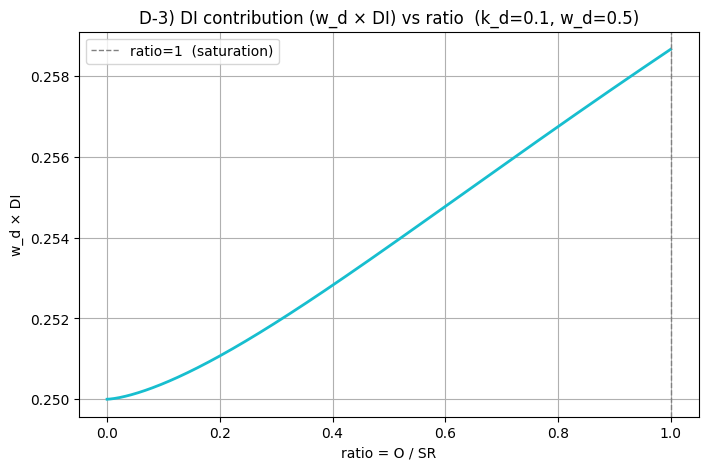

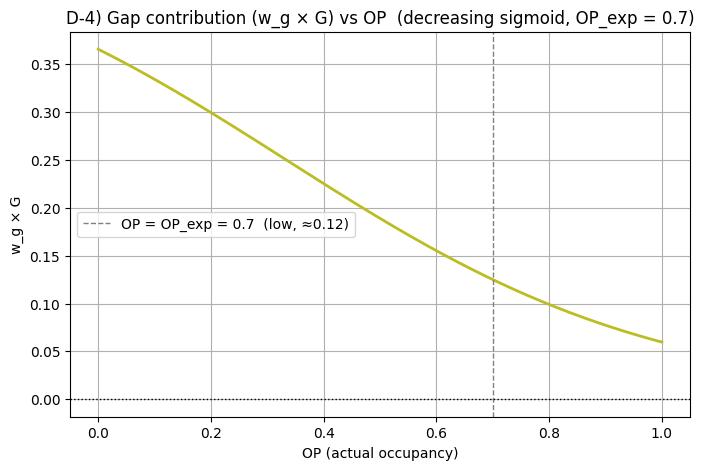

In [ ]:
# D-3) DI contribution (w_d * DI) vs ratio = O / SR  (gap fixed)
p = dict(DEFAULTS)
ratio_grid = np.linspace(1e-4, 1 - 1e-4, 400)
res = score_model(
    OP=p["OP"], OP_exp=p["OP_exp"],
    O=ratio_grid, SR=np.ones_like(ratio_grid),
    k_g=p["k_g"], k_d=p["k_d"], w_g=p["w_g"], w_d=p["w_d"],
    g0=p["g0"], order_exp=p["order_exp"],
    sales_pressure=p["sales_pressure"],
)
di_contrib = p["w_d"] * res["DI"]

plt.figure()
plt.plot(ratio_grid, di_contrib, color="tab:cyan", lw=2)
plt.axvline(1.0, color="gray", ls="--", lw=1, label="ratio=1  (saturation)")
plt.title(f"D-3) DI contribution (w_d × DI) vs ratio  (k_d={p['k_d']}, w_d={p['w_d']})")
plt.xlabel("ratio = O / SR")
plt.ylabel("w_d × DI")
plt.legend()
plt.show()

# D-4) Gap contribution (w_g * G) vs gap_pct  (oversold -> negative gap)
gap_pct_grid = np.linspace(p["chart_gap_min"], p["chart_gap_max"], 400)
G_grid = gap_function(gap_pct_grid / 100.0, p["k_g"], g_at_zero=p["g0"])
gap_contrib = p["w_g"] * G_grid

g_at_zero = p["w_g"] * gap_function(0.0, p["k_g"], g_at_zero=p["g0"])
g_at_full = p["w_g"] * gap_function(1.0, p["k_g"], g_at_zero=p["g0"])

plt.figure()
plt.plot(gap_pct_grid, gap_contrib, color="tab:olive", lw=2)
plt.axvline(0, color="green", ls=":", lw=1, label="هدف (gap=0)")
plt.axvline(float(gap_pct(p["OP"], p["OP_exp"])), color="red", ls="--", lw=1,
            label=f"gap فعلی = {float(gap_pct(p['OP'], p['OP_exp'])):.1f}%")
plt.axhline(g_at_zero, color="gray", ls=":", lw=1,
            label=f"0% gap -> {g_at_zero:.2f}")
plt.title(f"D-4) w_g×G vs gap_pct  (k_g={p['k_g']}, at 100% -> {g_at_full:.2f})")
plt.xlabel("gap_pct (%)")
plt.ylabel("w_g × G")
plt.legend()
plt.show()

## 5. Interactive input

`compute_score(OP, OP_exp, O, SR, ...)` prints **G**, **DI**, and **Score**.
The remaining coefficients (`k_g, k_d, w_g, w_d`) default to `DEFAULTS` but can be
overridden. If `ipywidgets` is available, run the last cell for sliders **and** the chart.

### فرمول کلی مدل

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

$$
\text{fill\_pct} = \frac{OP}{OP_{exp}} \times 100
\qquad\text{(چند \% از هدف پر شده)}
$$

$$
\text{gap\_pct} = 100 - \text{fill\_pct}
$$

$$
\text{gap\_unit} = \frac{\text{gap\_pct}}{100} \in [0,1]
$$

$$
\text{shift} = \ln\!\left(\frac{1 - g_0}{g_0}\right),
\quad g_0 = 0.25
$$

$$
G = \sigma\!\left(k_g \cdot \text{gap\_unit} - \text{shift}\right)
\quad\Longrightarrow\quad
\begin{cases}
\text{fill}=100\% & \Rightarrow G \approx g_0 \\[4pt]
\text{fill}=0\% \;(۰ از ۴۰) & \Rightarrow \text{gap\_unit}=1
\end{cases}
$$

$$
DI_{raw} = O^{1.5}\cdot SR,
\qquad
DI = \sigma\!\left(k_d \cdot \ln(1 + DI_{raw})\right)
$$

$$
\text{Score} =
\begin{cases}
w_g\, G + w_d\, DI & \text{اگر sales\_pressure} = \text{True}\\[6pt]
w_g\, G & \text{اگر sales\_pressure} = \text{False}
\end{cases}
$$

### معنی پارامترها

- **OP** — میزان پر بودن فعلی اتوبوس (بین ۰ و ۱).
- **fill_pct** — چند درصد از `OP_exp` پر شده: `OP / OP_exp × 100` (۰ از ۴۰ → ۰٪).
- **gap_pct** — درصد باقی‌مانده تا هدف: `100 - fill_pct` (۰ از ۴۰ → گپ ۱۰۰٪).
- **OP_exp** — میزان پر بودن مورد انتظار / هدف (بین ۰ و ۱).
- **O** — تعداد سفارش‌ها (Order count).
- **SR** — نرخ فروش (Sales rate).
- **k_g** — حساسیت سیگموید روی گپ؛ وقتی gap_pct=100% باشد آرگومان سیگموید = k_g (پیش‌فرض ۳).
- **k_d** — ضریب حساسیت شدت تقاضا.
- **w_g** — وزن سیگنال گپ (G) در امتیاز نهایی.
- **w_d** — وزن شدت تقاضا (DI) در امتیاز نهایی.
- **sales_pressure** — اگر True باشد ترم تقاضا (DI) هم به امتیاز اضافه می‌شود؛ در غیر این صورت فقط بخش گپ/OP لحاظ می‌شود.

In [ ]:
def compute_score(OP, OP_exp, O, SR,
                  k_g=DEFAULTS["k_g"], k_d=DEFAULTS["k_d"],
                  w_g=DEFAULTS["w_g"], w_d=DEFAULTS["w_d"],
                  g0=DEFAULTS["g0"], order_exp=DEFAULTS["order_exp"],
                  sales_pressure=DEFAULTS["sales_pressure"],
                  verbose=True):
    """Compute and print G, DI and the final Score for scalar inputs.

    sales_pressure True  -> Score includes the demand-intensity (DI) term.
    sales_pressure False -> Score uses only the OP/gap term.

    Returns the result dict so it can be used programmatically too.
    """
    res = score_model(
        OP, OP_exp, O, SR, k_g, k_d, w_g, w_d, sales_pressure,
        g0=g0, order_exp=order_exp,
    )

    if verbose:
        mode = "sales pressure (gap + DI)" if sales_pressure else "OP only (gap)"
        shift = float(res["shift"])
        print("Inputs:")
        print(f"  OP             = {OP}")
        print(f"  OP_exp         = {OP_exp}")
        print(f"  O              = {O}")
        print(f"  SR             = {SR}")
        print(f"  sales_pressure = {sales_pressure}  -> mode: {mode}")
        print(f"  k_g={k_g}, k_d={k_d}, w_g={w_g}, w_d={w_d}")
        print(f"  g0={g0}, order_exp={order_exp}, shift={shift:.4f}")
        print("-" * 32)
        print("Intermediate:")
        print(f"  fill_pct = {float(res['fill_pct']):.2f}%  (از هدف پر شده)")
        print(f"  gap_pct  = {float(res['gap_pct']):.2f}%  (منفی = فروش بیش از انتظار)")
        print(f"  gap      = {float(res['gap']):.4f}  (فاصله مطلق OP_exp-OP)")
        print(f"  G        = {float(res['G']):.4f}")
        print(f"  DI_raw  = {float(res['DI_raw']):.4f}")
        print(f"  DI      = {float(res['DI']):.4f}")
        print("-" * 32)
        print(f"  SCORE   = {float(res['Score']):.4f}")

    return res


# Example calls: with and without sales pressure.
_ = compute_score(OP=0.55, OP_exp=0.70, O=50, SR=0.65, sales_pressure=True)
print("=" * 32)
_ = compute_score(OP=0.55, OP_exp=0.70, O=50, SR=0.65, sales_pressure=False)

Inputs:
  OP             = 0.55
  OP_exp         = 0.7
  O              = 50
  SR             = 0.65
  sales_pressure = True  -> mode: sales pressure (gap + DI)
  k_g=3.0, k_d=0.1, w_g=0.5, w_d=0.5
--------------------------------
Intermediate:
  gap     = 0.1500
  G       = 0.3433
  DI_raw  = 229.8097
  DI      = 0.6328
--------------------------------
  SCORE   = 0.4880
Inputs:
  OP             = 0.55
  OP_exp         = 0.7
  O              = 50
  SR             = 0.65
  sales_pressure = False  -> mode: OP only (gap)
  k_g=3.0, k_d=0.1, w_g=0.5, w_d=0.5
--------------------------------
Intermediate:
  gap     = 0.1500
  G       = 0.3433
  DI_raw  = 229.8097
  DI      = 0.6328
--------------------------------
  SCORE   = 0.1717


In [ ]:
def build_discount_formula_md(OP, OP_exp, O, SR, k_g, k_d, w_g, w_d, g0, order_exp, sales_pressure, res):
    """LaTeX markdown: general discount formula + current numeric values."""
    fill = float(res["fill_pct"])
    gap = float(res["gap_pct"])
    g_unit = float(res["gap_unit"])
    G = float(res["G"])
    DI = float(res["DI"])
    DI_raw = float(res["DI_raw"])
    score = float(res["Score"])
    shift = float(res["shift"])
    gap_arg = k_g * g_unit - shift

    if sales_pressure:
        score_tex = (
            r"\text{Score} = w_g \cdot G + w_d \cdot DI"
            rf" = {w_g:.2f}\times{G:.4f} + {w_d:.2f}\times{DI:.4f}"
            rf" = \mathbf{{{score:.4f}}}"
        )
    else:
        score_tex = (
            r"\text{Score} = w_g \cdot G"
            rf" = {w_g:.2f}\times{G:.4f}"
            rf" = \mathbf{{{score:.4f}}}"
        )

    return f"""
<div style="font-family:Segoe UI,Tahoma,sans-serif;line-height:1.6;padding:4px 8px;">

**فرمول کلی تخفیف / امتیاز**

$$\\sigma(x)=\\frac{{1}}{{1+e^{{-x}}}}$$

$$\\text{{fill\\_pct}}=\\frac{{OP}}{{OP_{{exp}}}}\\times100
\\qquad
\\text{{gap\\_pct}}=100-\\text{{fill\\_pct}}
\\qquad
\\text{{gap\\_unit}}=\\frac{{\\text{{gap\\_pct}}}}{{100}}$$

        $$\\text{{shift}}=\\ln\\!\\left(\\frac{{1-g_0}}{{g_0}}\\right),\\; g_0={g0:.2f}$$

        $$G=\\sigma\\!\\left(k_g\\cdot\\text{{gap\\_unit}}-\\text{{shift}}\\right)$$

        $$DI_{{raw}}=O^{{{order_exp:.1f}}}\\cdot SR,\\qquad
        DI=\\sigma\\!\\left(k_d\\cdot\\ln(1+DI_{{raw}})\\right)$$

$$\\text{{Score}}=
\\begin{{cases}}
w_g G + w_d DI & \\text{{اگر sales\\_pressure}} \\\\
w_g G & \\text{{در غیر این صورت}}
\\end{{cases}}$$

---

**با مقادیر فعلی**

$$\\text{{fill\\_pct}}=\\frac{{{OP:.2f}}}{{{OP_exp:.2f}}}\\times100={fill:.1f}\\%
\\;\\Rightarrow\\;
\\text{{gap\\_pct}}={gap:.1f}\\%
\\;\\Rightarrow\\;
\\text{{gap\\_unit}}={g_unit:.4f}$$

        $$G=\\sigma({k_g:.2f}\\times{g_unit:.4f}-{shift:.4f})
        =\\sigma({gap_arg:.4f})={G:.4f}$$

$$DI_{{raw}}={DI_raw:.2f},\\quad DI={DI:.4f}$$

$${score_tex}$$

</div>
"""


def _make_plotly_figure(OP, OP_exp, k_g, w_g, g0, res,
                        chart_gap_min=-50.0, chart_gap_max=100.0):
    gap_x = np.linspace(chart_gap_min, chart_gap_max, 400)
    y_curve = w_g * gap_function(gap_x / 100.0, k_g, g_at_zero=g0)
    pt_x = float(res["gap_pct"])
    pt_y = w_g * float(res["G"])

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=gap_x, y=y_curve, mode="lines", name="w_g · G(gap%)",
        line=dict(color="olive", width=2),
    ))
    fig.add_trace(go.Scatter(
        x=[pt_x], y=[pt_y], mode="markers",
        name=f"نقطه فعلی ({pt_x:.1f}%)",
        marker=dict(color="red", size=11),
    ))
    fig.add_vline(x=0, line_dash="dot", line_color="green",
                  annotation_text="هدف (gap=0)")
    fig.add_vline(x=pt_x, line_dash="dash", line_color="gray",
                  annotation_text=f"gap={pt_x:.1f}%")
    fig.update_layout(
        title="نمودار سیگنال تخفیف (gap<0 = فروش بیش از انتظار)",
        xaxis_title="gap_pct (%) — منفی = oversold",
        yaxis_title="w_g · G",
        dragmode="zoom",
        hovermode="x unified",
        template="plotly_white",
        margin=dict(l=40, r=20, t=50, b=40),
        height=420,
    )
    fig.update_xaxes(rangeslider_visible=True, range=[chart_gap_min, chart_gap_max])
    return fig


def display_chart_with_formula(OP, OP_exp, O, SR, k_g, k_d, w_g, w_d, g0, order_exp,
                               sales_pressure, res,
                               chart_gap_min=-50.0, chart_gap_max=100.0):
    """Side-by-side: LaTeX formula (left) + zoomable chart (right)."""
    md = build_discount_formula_md(
        OP, OP_exp, O, SR, k_g, k_d, w_g, w_d, g0, order_exp, sales_pressure, res
    )

    if not _HAS_WIDGETS:
        display(Markdown(md))
        if _HAS_PLOTLY:
            _make_plotly_figure(
                OP, OP_exp, k_g, w_g, g0, res,
                chart_gap_min=chart_gap_min, chart_gap_max=chart_gap_max,
            ).show()
        else:
            gap_x = np.linspace(chart_gap_min, chart_gap_max, 400)
            y_curve = w_g * gap_function(gap_x / 100.0, k_g, g_at_zero=g0)
            pt_x = float(res["gap_pct"])
            plt.figure(figsize=(8, 4))
            plt.plot(gap_x, y_curve, color="tab:olive", lw=2)
            plt.axvline(0, color="green", ls=":", lw=1, label="هدف (gap=0)")
            plt.scatter([pt_x], [w_g * float(res["G"])], color="tab:red", zorder=5)
            plt.xlabel("gap_pct (%)")
            plt.ylabel("w_g · G")
            plt.xlim(chart_gap_min, chart_gap_max)
            plt.tight_layout()
            plt.show()
        return

    formula_out = widgets.Output(
        layout=widgets.Layout(
            width="38%", min_width="300px", padding="6px",
            border="1px solid #ccc", overflow_y="auto",
        ),
    )
    with formula_out:
        display(Markdown(md))
    formula_box = formula_out

    if _HAS_PLOTLY:
        fig = _make_plotly_figure(
            OP, OP_exp, k_g, w_g, g0, res,
            chart_gap_min=chart_gap_min, chart_gap_max=chart_gap_max,
        )
        try:
            chart_widget = go.FigureWidget(fig)
        except Exception:
            chart_out = widgets.Output()
            with chart_out:
                fig.show()
            chart_widget = chart_out
        chart_box = widgets.VBox(
            [chart_widget],
            layout=widgets.Layout(width="62%", min_width="360px"),
        )
    else:
        chart_out = widgets.Output()
        with chart_out:
            gap_x = np.linspace(chart_gap_min, chart_gap_max, 400)
            y_curve = w_g * gap_function(gap_x / 100.0, k_g, g_at_zero=g0)
            pt_x = float(res["gap_pct"])
            plt.figure(figsize=(7, 4))
            plt.plot(gap_x, y_curve, color="tab:olive", lw=2)
            plt.axvline(0, color="green", ls=":", lw=1)
            plt.scatter([pt_x], [w_g * float(res["G"])], color="tab:red", zorder=5)
            plt.xlabel("gap_pct (%)")
            plt.ylabel("w_g · G")
            plt.title(f"Score = {float(res['Score']):.3f}")
            plt.xlim(chart_gap_min, chart_gap_max)
            plt.tight_layout()
            plt.show()
        chart_box = widgets.VBox([chart_out], layout=widgets.Layout(width="62%"))

    row = widgets.HBox(
        [formula_box, chart_box],
        layout=widgets.Layout(width="100%", align_items="flex-start"),
    )

    return row


def interactive_panel(OP, OP_exp, O, SR, k_g, k_d, w_g, w_d, g0, order_exp,
                      sales_pressure, chart_gap_min, chart_gap_max):
    """Print breakdown + show formula beside chart."""
    res = compute_score(
        OP, OP_exp, O, SR, k_g, k_d, w_g, w_d,
        g0=g0, order_exp=order_exp,
        sales_pressure=sales_pressure, verbose=True,
    )
    return display_chart_with_formula(
        OP, OP_exp, O, SR, k_g, k_d, w_g, w_d, g0, order_exp,
        sales_pressure, res,
        chart_gap_min=chart_gap_min, chart_gap_max=chart_gap_max,
    )


# Wide labels so the Persian descriptions are not truncated.
_LBL = {"description_width": "initial"}

# Interactive sliders (requires ipywidgets). Falls back to a plain call + plot.
if _HAS_WIDGETS:
    widgets.interact(
        interactive_panel,
        OP=widgets.FloatSlider(value=DEFAULTS["OP"], min=0.0, max=1.0, step=0.01,
                               description="OP (پر بودن فعلی)", style=_LBL),
        OP_exp=widgets.FloatSlider(value=DEFAULTS["OP_exp"], min=0.0, max=1.0, step=0.01,
                                   description="OP_exp (پر بودن مورد انتظار)", style=_LBL),
        O=widgets.FloatSlider(value=float(DEFAULTS["O"]), min=0.0, max=200.0, step=1.0,
                              description="O (تعداد سفارش)", style=_LBL),
        SR=widgets.FloatSlider(value=float(DEFAULTS["SR"]), min=0.0, max=200.0, step=1.0,
                               description="SR (نرخ فروش)", style=_LBL),
        k_g=widgets.FloatSlider(value=DEFAULTS["k_g"], min=0.0, max=10.0, step=0.1,
                                description="k_g (حساسیت گپ)", style=_LBL),
        k_d=widgets.FloatSlider(value=DEFAULTS["k_d"], min=0.0, max=5.0, step=0.1,
                                description="k_d (حساسیت تقاضا)", style=_LBL),
        w_g=widgets.FloatSlider(value=DEFAULTS["w_g"], min=0.0, max=1.0, step=0.05,
                                description="w_g (وزن گپ)", style=_LBL),
        w_d=widgets.FloatSlider(value=DEFAULTS["w_d"], min=0.0, max=1.0, step=0.05,
                                description="w_d (وزن تقاضا)", style=_LBL),
        g0=widgets.FloatSlider(value=DEFAULTS["g0"], min=0.01, max=0.99, step=0.01,
                               description="g0 (G وقتی گپ=۰)", style=_LBL),
        order_exp=widgets.FloatSlider(value=DEFAULTS["order_exp"], min=0.1, max=5.0, step=0.1,
                                      description="order_exp (توان O)", style=_LBL),
        chart_gap_min=widgets.FloatSlider(value=DEFAULTS["chart_gap_min"], min=-100.0, max=0.0, step=5.0,
                                          description="chart_gap_min (%)", style=_LBL),
        chart_gap_max=widgets.FloatSlider(value=DEFAULTS["chart_gap_max"], min=0.0, max=150.0, step=5.0,
                                          description="chart_gap_max (%)", style=_LBL),
        sales_pressure=widgets.Checkbox(value=DEFAULTS["sales_pressure"],
                                        description="sales_pressure (فشار فروش)",
                                        style=_LBL),
    )
else:
    print("ipywidgets not available -- edit the values below and re-run:")
    interactive_panel(**DEFAULTS)

interactive(children=(FloatSlider(value=0.55, description='OP (پر بودن فعلی)', max=1.0, step=0.01, style=Slide…